# US Recession 2025 Forecast - Indicator Analysis

This notebook provides deep analysis of individual economic indicators and their relationship to historical recessions.

## Objectives
1. Analyze each indicator individually
2. Plot indicators against historical recession periods
3. Calculate lead/lag relationships
4. Assess signal quality and predictive power
5. Identify optimal thresholds for recession signals

In [37]:
# Add project root to path
import sys
from pathlib import Path

# Add project root (3 levels up from this notebook)
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/simon/Documents/perso/polymarket-simulator


In [38]:
# Import data fetching utilities
from forecasts.us_recession_2025.data_v2 import fetch_economic_indicators_v2
from forecasts.us_recession_2025.config import DATA_SOURCES
from forecasts.us_recession_2025.config_v2 import V2_INDICATOR_SERIES, get_all_indicator_thresholds
from lib.data_fetcher import fetch_fred_data

# Import data analysis libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Historical Recession Periods

Define NBER recession periods for analysis.

In [39]:
# Historical US recession periods (NBER dates)
RECESSION_PERIODS = [
    ('2020-02-01', '2020-04-30'),  # COVID-19 recession
    ('2007-12-01', '2009-06-30'),  # Great Recession
    ('2001-03-01', '2001-11-30'),  # Dot-com bubble recession
]

# Convert to datetime
recession_periods = [(pd.to_datetime(start), pd.to_datetime(end)) 
                     for start, end in RECESSION_PERIODS]

print(f"Tracking {len(recession_periods)} historical recession periods")

Tracking 3 historical recession periods


## Load Historical Data

Fetching 25 years of historical data to cover all recession periods.

In [40]:
# Fetch 25 years of data to cover all recession periods from 2000-2025
lookback_days = 365 * 27  # 25 years
end_date = datetime.now()
start_date = end_date - timedelta(days=lookback_days)

print(f"Fetching data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

Fetching data from 1998-11-29 to 2025-11-22


In [41]:
# Get all indicator series IDs
all_indicators = {**DATA_SOURCES, **V2_INDICATOR_SERIES}

# Fetch data for each indicator
indicator_data = {}
for indicator_name, series_id in all_indicators.items():
    try:
        print(f"Fetching {indicator_name} ({series_id})...")
        data = fetch_fred_data(
            series_id=series_id,
            start_date=start_date.strftime('%Y-%m-%d'),
            end_date=end_date.strftime('%Y-%m-%d')
        )
        indicator_data[indicator_name] = data
    except Exception as e:
        print(f"  ⚠ Error fetching {indicator_name}: {e}")
        indicator_data[indicator_name] = None

print(f"\n✓ Successfully fetched data for {len([v for v in indicator_data.values() if v])} indicators")

Fetching yield_curve (T10Y2Y)...
Fetching unemployment (UNRATE)...
Fetching gdp (A191RL1Q225SBEA)...
Fetching consumer_confidence (UMCSENT)...
Fetching leading_indicators (USSLIND)...
Fetching jobless_claims (ICSA)...
Fetching credit_spread (BAA10Y)...
Fetching housing_starts (HOUST)...
Fetching manufacturing_pmi (NAPM)...


FRED API request failed with status 400: Bad Request.  The series does not exist.


  ⚠ Error fetching manufacturing_pmi: FRED API request failed with status 400: Bad Request.  The series does not exist.
Fetching retail_sales (RSXFS)...
Fetching oil_price (DCOILWTICO)...
Fetching vix (VIXCLS)...

✓ Successfully fetched data for 11 indicators


In [42]:
# Convert to DataFrames and resample to daily frequency
dfs = {}

for indicator_name, data in indicator_data.items():
    if data is None:
        continue
    
    observations = data.get('observations', [])
    if not observations:
        continue
    
    df = pd.DataFrame(observations)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df[['date', 'value']].set_index('date')
    df.columns = [indicator_name]
    
    # CRITICAL FIX: Resample to daily and forward-fill for monthly/quarterly data
    df = df.resample('D').ffill()
    
    dfs[indicator_name] = df

# Combine all indicators
combined_df = pd.concat(dfs.values(), axis=1)
combined_df = combined_df.sort_index()

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Date range: {combined_df.index.min()} to {combined_df.index.max()}")
print(f"\nIndicators: {list(combined_df.columns)}")

Combined DataFrame shape: (9914, 11)
Date range: 1998-10-01 00:00:00 to 2025-11-21 00:00:00

Indicators: ['yield_curve', 'unemployment', 'gdp', 'consumer_confidence', 'leading_indicators', 'jobless_claims', 'credit_spread', 'housing_starts', 'retail_sales', 'oil_price', 'vix']


## Individual Indicator Analysis

Deep dive into each indicator with recession periods marked.

In [43]:
# Helper function to mark recession periods
def mark_recessions(ax, recession_periods, alpha=0.2, color='red'):
    """Mark recession periods on a plot"""
    for start, end in recession_periods:
        ax.axvspan(start, end, alpha=alpha, color=color, label='Recession')

# Helper function to calculate lead/lag correlation
def calculate_lead_lag(indicator_series, recession_indicator, max_lag=12):
    """Calculate correlation at different lags"""
    correlations = []
    lags = range(-max_lag, max_lag + 1)
    
    for lag in lags:
        if lag < 0:
            # Indicator leads recession
            corr = indicator_series.shift(-lag).corr(recession_indicator)
        else:
            # Indicator lags recession
            corr = indicator_series.corr(recession_indicator.shift(lag))
        correlations.append(corr)
    
    return list(lags), correlations

print("✓ Helper functions defined")

✓ Helper functions defined


In [44]:
# Create recession indicator (binary: 1 during recession, 0 otherwise)
recession_indicator = pd.Series(0, index=combined_df.index)

for start, end in recession_periods:
    mask = (combined_df.index >= start) & (combined_df.index <= end)
    recession_indicator[mask] = 1

print(f"Recession indicator created: {recession_indicator.sum()} recession days out of {len(recession_indicator)} total days")

Recession indicator created: 943 recession days out of 9914 total days


### Yield Curve Analysis

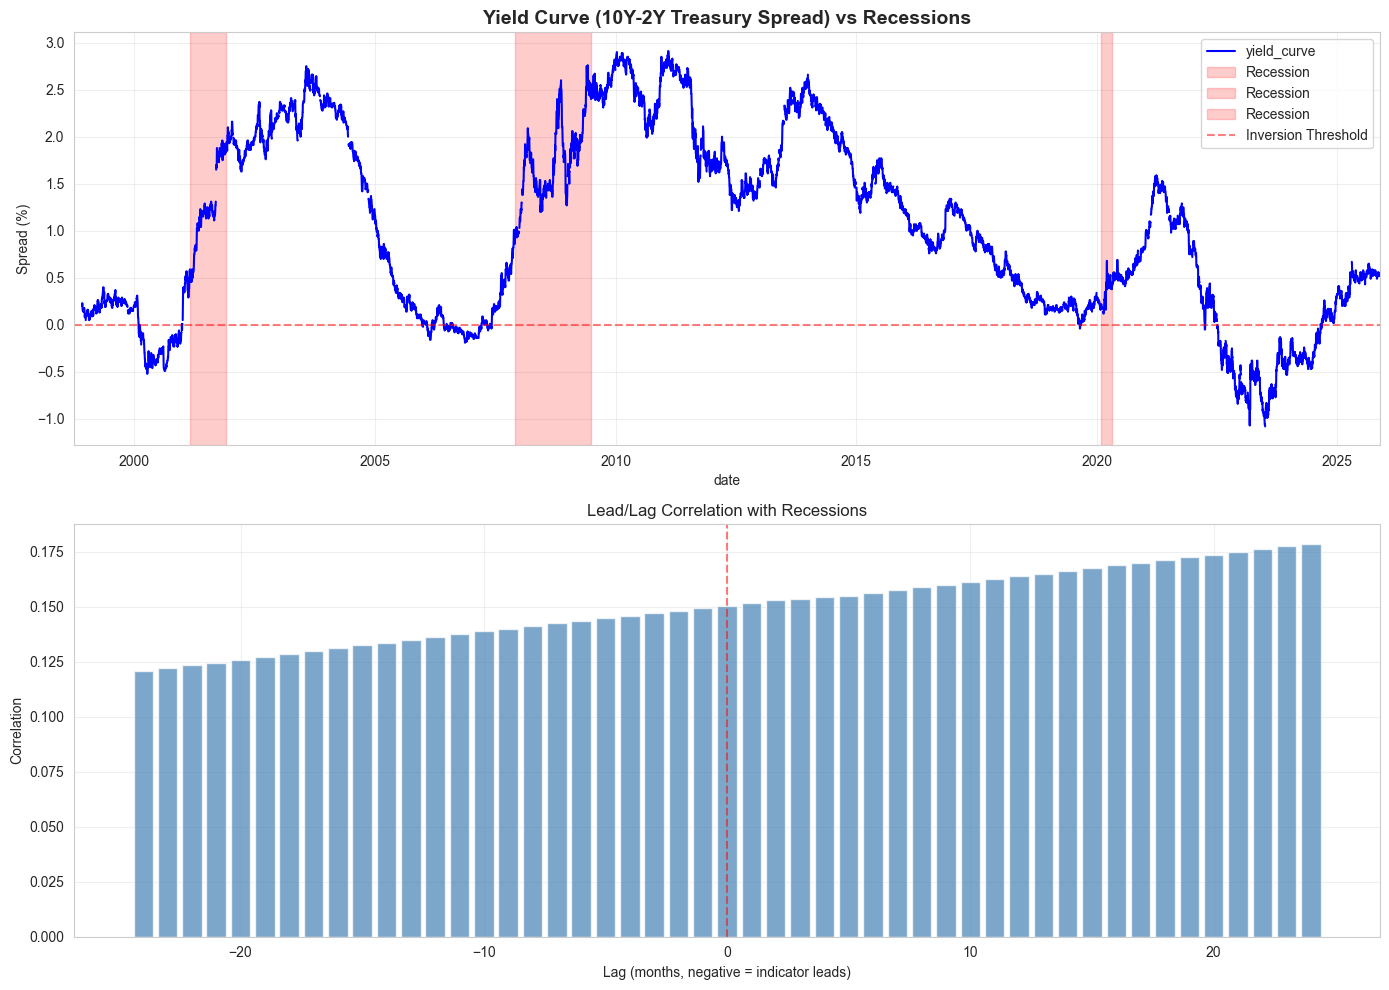


Yield Curve Statistics:
Mean: 1.03%
Std Dev: 0.97%
Min: -1.08%
Max: 2.91%
Current: 0.55%

Inversion periods: 1421 days (14.3%)


In [45]:
if 'yield_curve' in combined_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Time series with recessions
    ax1 = axes[0]
    combined_df['yield_curve'].plot(ax=ax1, linewidth=1.5, color='blue')
    mark_recessions(ax1, recession_periods)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Inversion Threshold')
    ax1.set_title('Yield Curve (10Y-2Y Treasury Spread) vs Recessions', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Spread (%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Lead/lag correlation
    ax2 = axes[1]
    lags, correlations = calculate_lead_lag(combined_df['yield_curve'].dropna(), recession_indicator, max_lag=24)
    ax2.bar(lags, correlations, color='steelblue', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax2.set_title('Lead/Lag Correlation with Recessions', fontsize=12)
    ax2.set_xlabel('Lag (months, negative = indicator leads)')
    ax2.set_ylabel('Correlation')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\nYield Curve Statistics:")
    print(f"Mean: {combined_df['yield_curve'].mean():.2f}%")
    print(f"Std Dev: {combined_df['yield_curve'].std():.2f}%")
    print(f"Min: {combined_df['yield_curve'].min():.2f}%")
    print(f"Max: {combined_df['yield_curve'].max():.2f}%")
    print(f"Current: {combined_df['yield_curve'].iloc[-1]:.2f}%")
    
    # Inversion analysis
    inversions = combined_df['yield_curve'] < 0
    print(f"\nInversion periods: {inversions.sum()} days ({inversions.sum()/len(inversions)*100:.1f}%)")
else:
    print("Yield curve data not available")

### Unemployment Rate Analysis

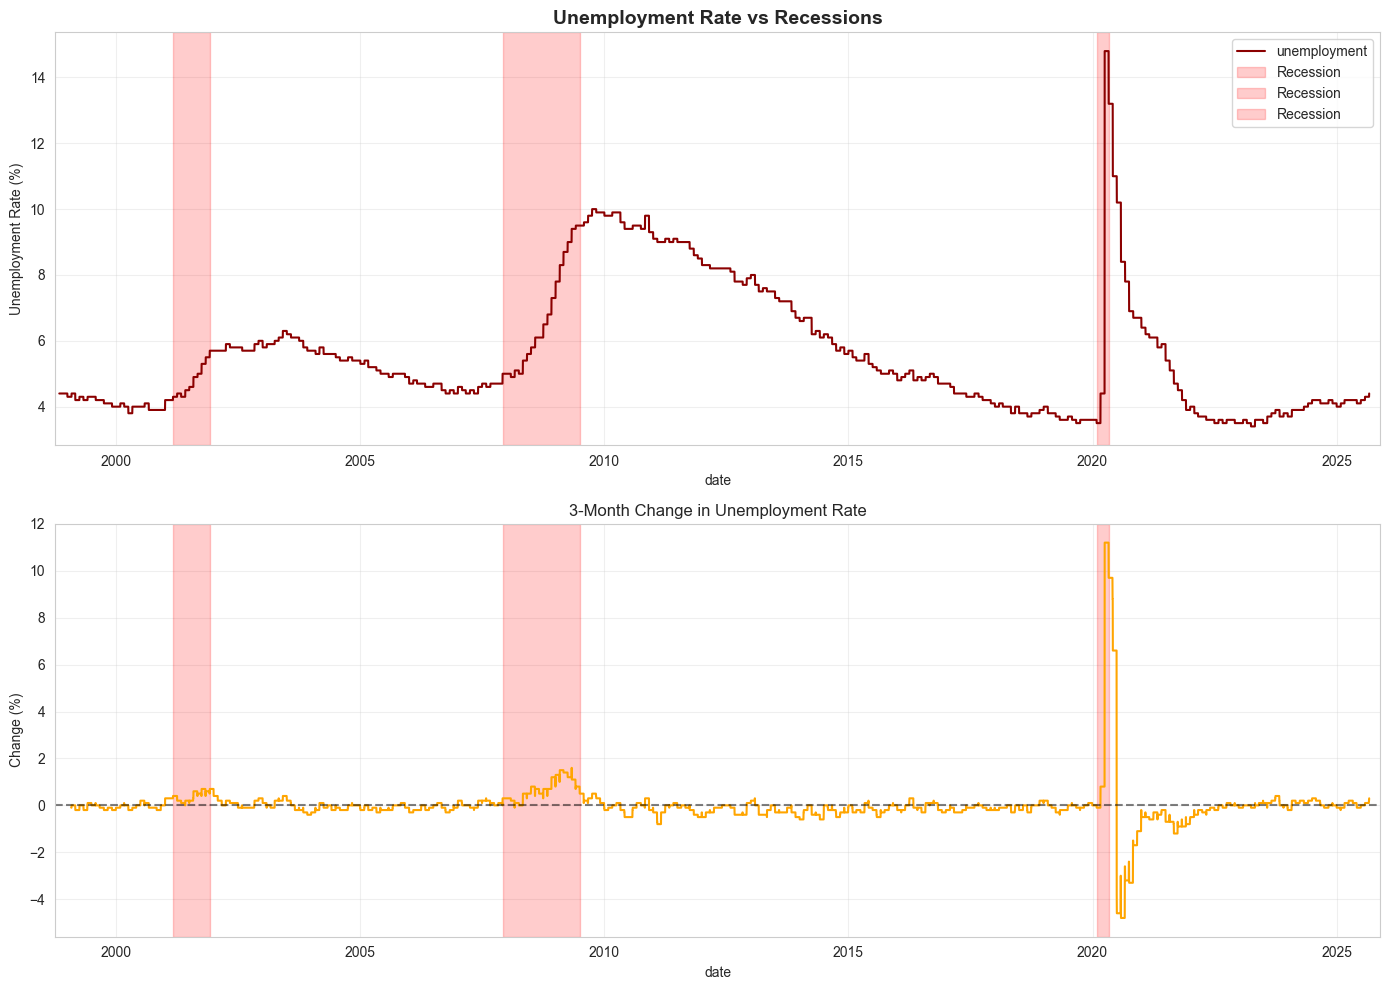


Unemployment Rate Statistics:
Mean: 5.59%
Current: nan%
Peak (25yr): 14.80%
Trough (25yr): 3.40%


In [46]:
if 'unemployment' in combined_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Time series
    ax1 = axes[0]
    combined_df['unemployment'].plot(ax=ax1, linewidth=1.5, color='darkred')
    mark_recessions(ax1, recession_periods)
    ax1.set_title('Unemployment Rate vs Recessions', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Unemployment Rate (%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Rate of change
    ax2 = axes[1]
    unemployment_change = combined_df['unemployment'].diff(periods=90)  # 3-month change
    unemployment_change.plot(ax=ax2, linewidth=1.5, color='orange')
    mark_recessions(ax2, recession_periods)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_title('3-Month Change in Unemployment Rate', fontsize=12)
    ax2.set_ylabel('Change (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\nUnemployment Rate Statistics:")
    print(f"Mean: {combined_df['unemployment'].mean():.2f}%")
    print(f"Current: {combined_df['unemployment'].iloc[-1]:.2f}%")
    print(f"Peak (25yr): {combined_df['unemployment'].max():.2f}%")
    print(f"Trough (25yr): {combined_df['unemployment'].min():.2f}%")
else:
    print("Unemployment data not available")

### All Other Indicators Analysis

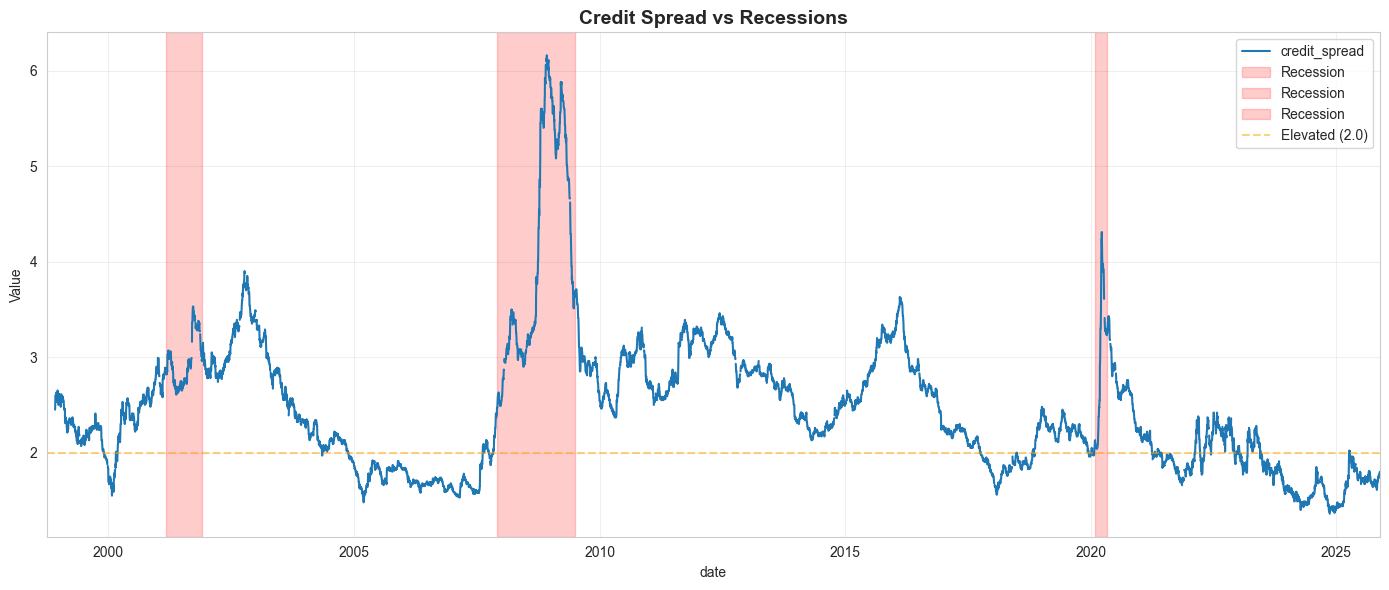


Credit Spread Statistics:
Mean: 2.47
Current: nan
Min: 1.36
Max: 6.16



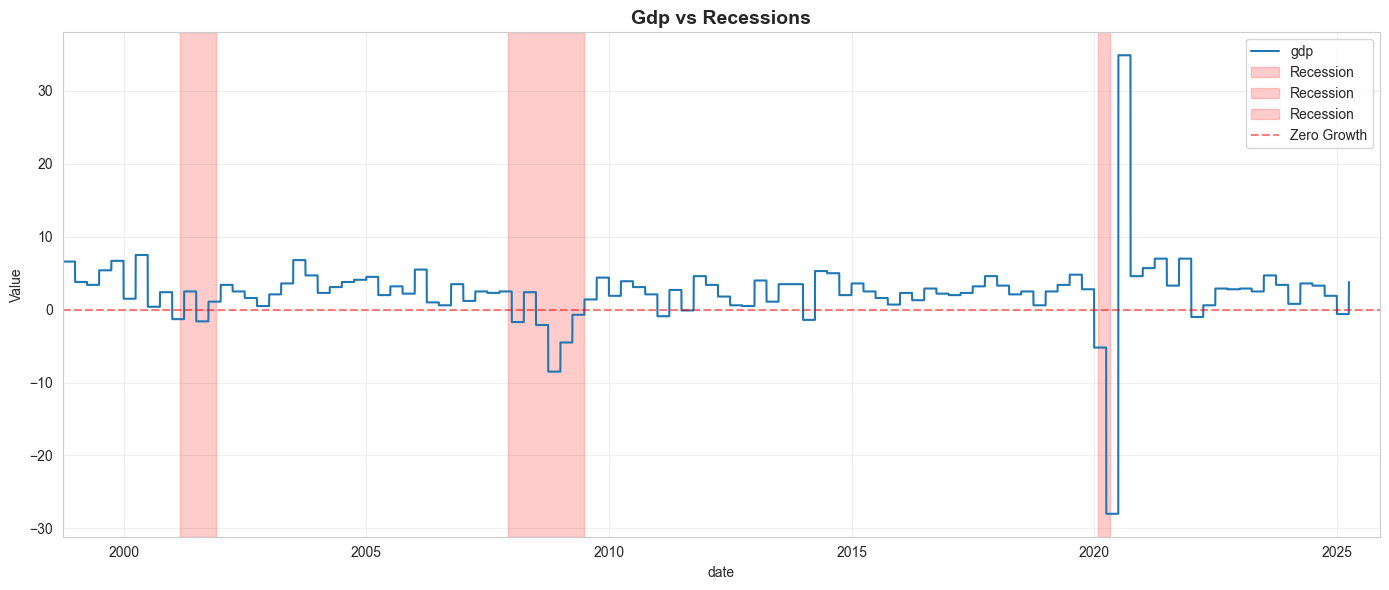


Gdp Statistics:
Mean: 2.40
Current: nan
Min: -28.00
Max: 34.90



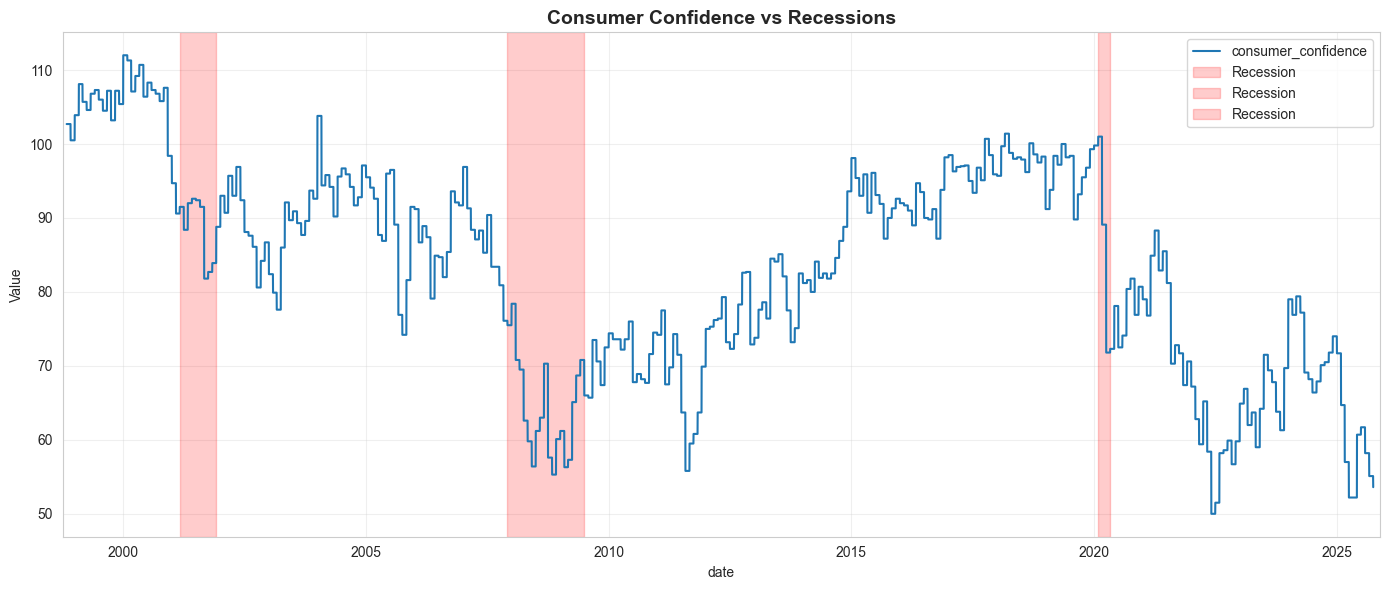


Consumer Confidence Statistics:
Mean: 83.17
Current: nan
Min: 50.00
Max: 112.00



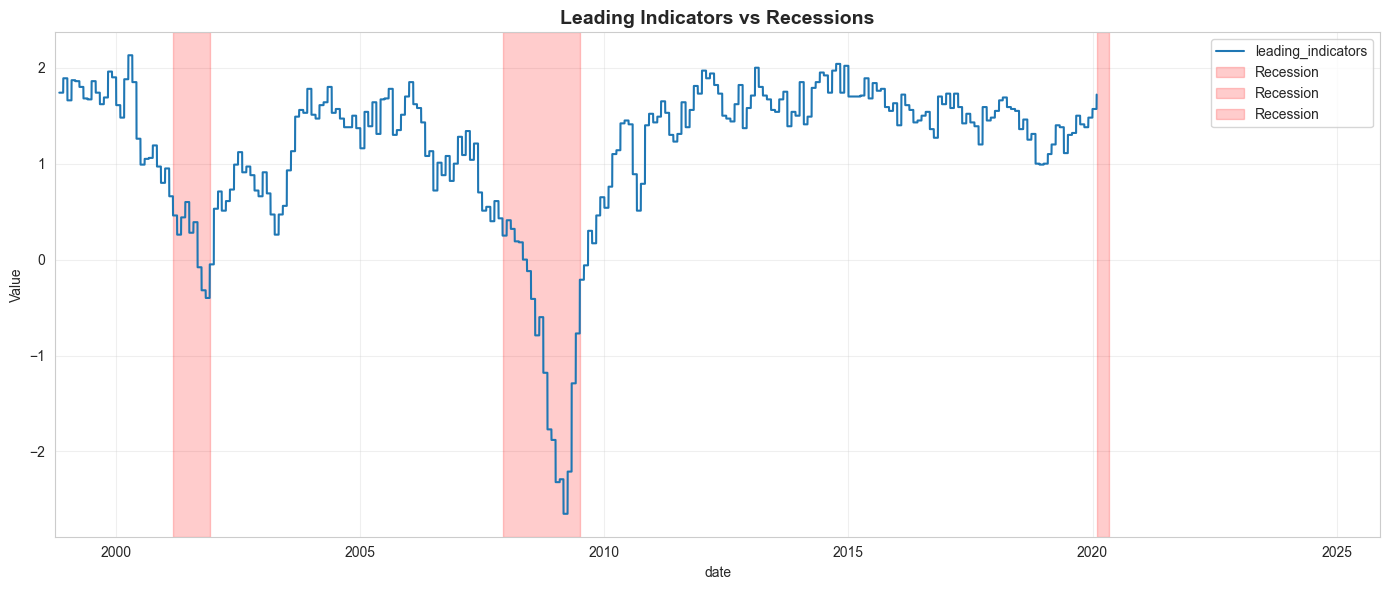


Leading Indicators Statistics:
Mean: 1.15
Current: nan
Min: -2.65
Max: 2.13



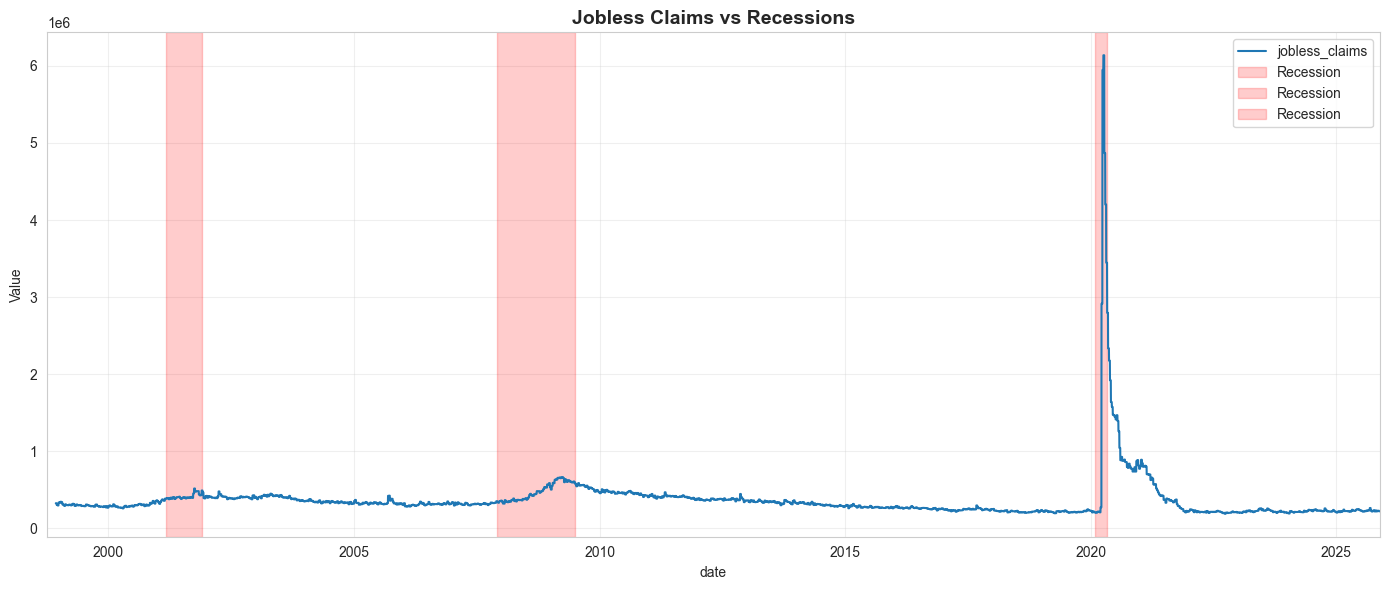


Jobless Claims Statistics:
Mean: 368097.33
Current: nan
Min: 189000.00
Max: 6137000.00



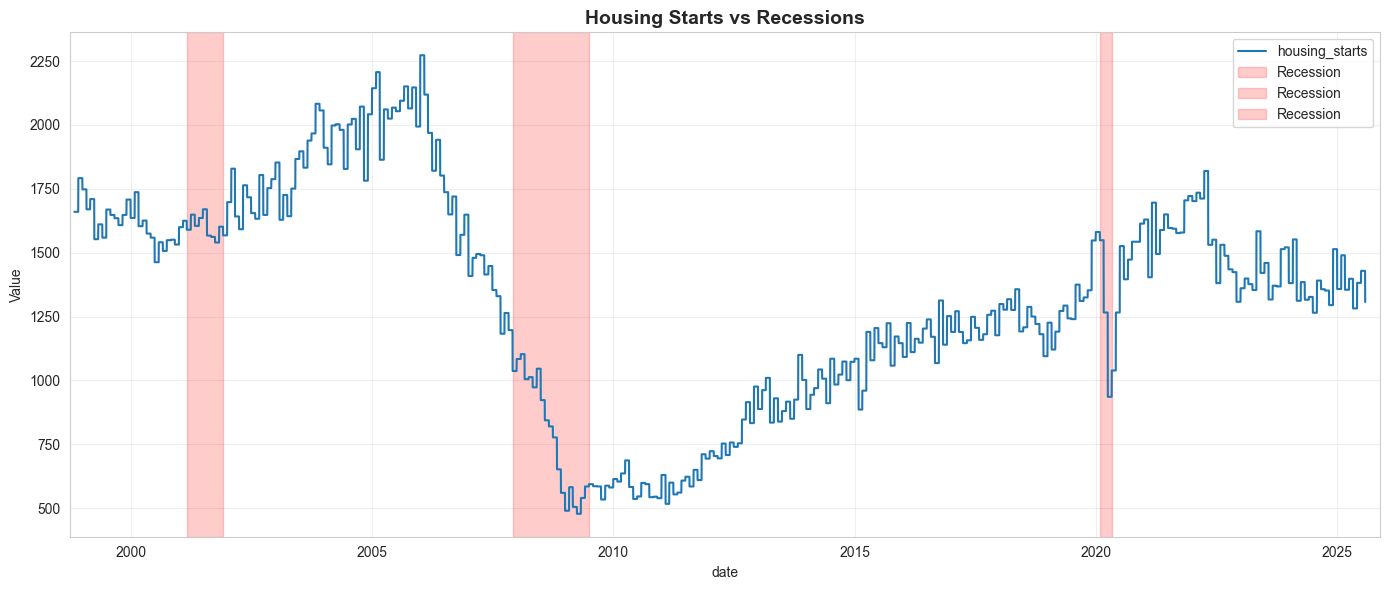


Housing Starts Statistics:
Mean: 1322.81
Current: nan
Min: 478.00
Max: 2273.00



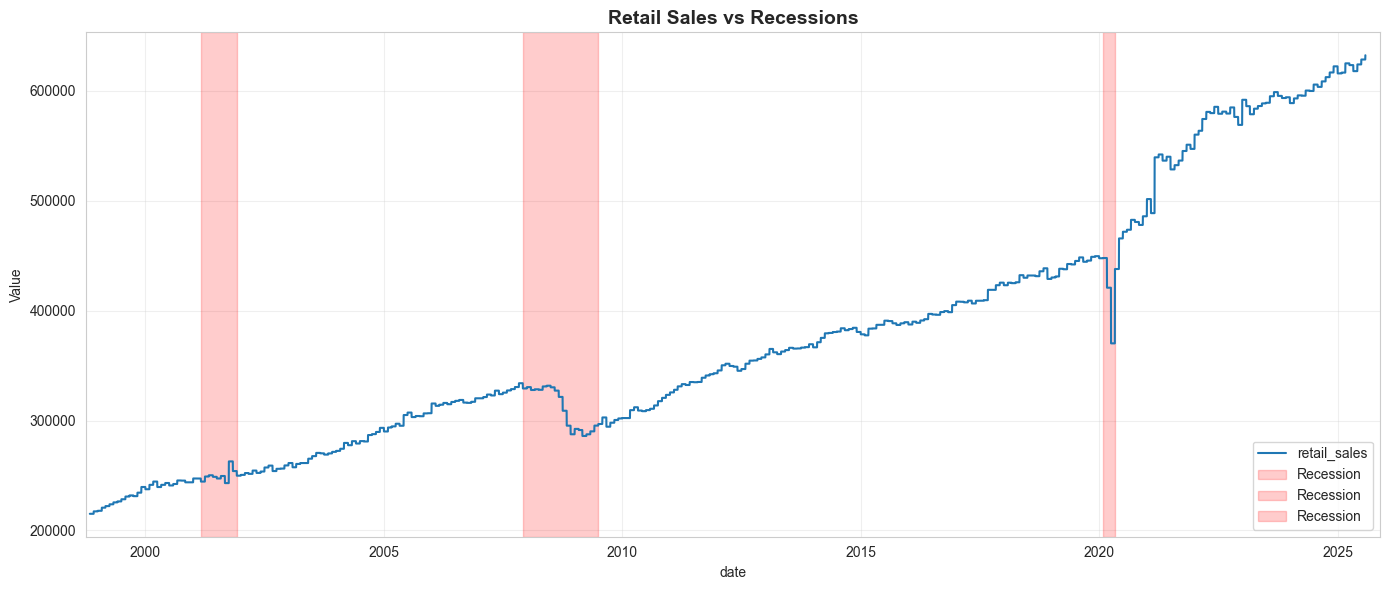


Retail Sales Statistics:
Mean: 375586.20
Current: nan
Min: 215194.00
Max: 632490.00



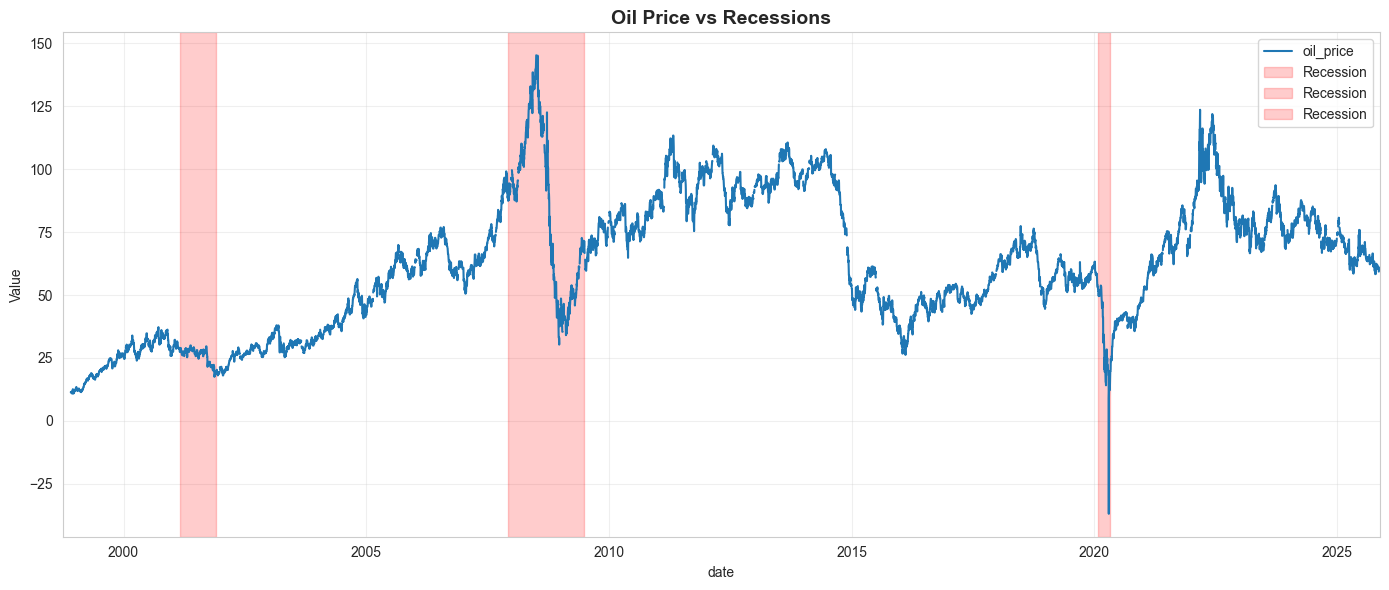


Oil Price Statistics:
Mean: 62.09
Current: nan
Min: -36.98
Max: 145.31



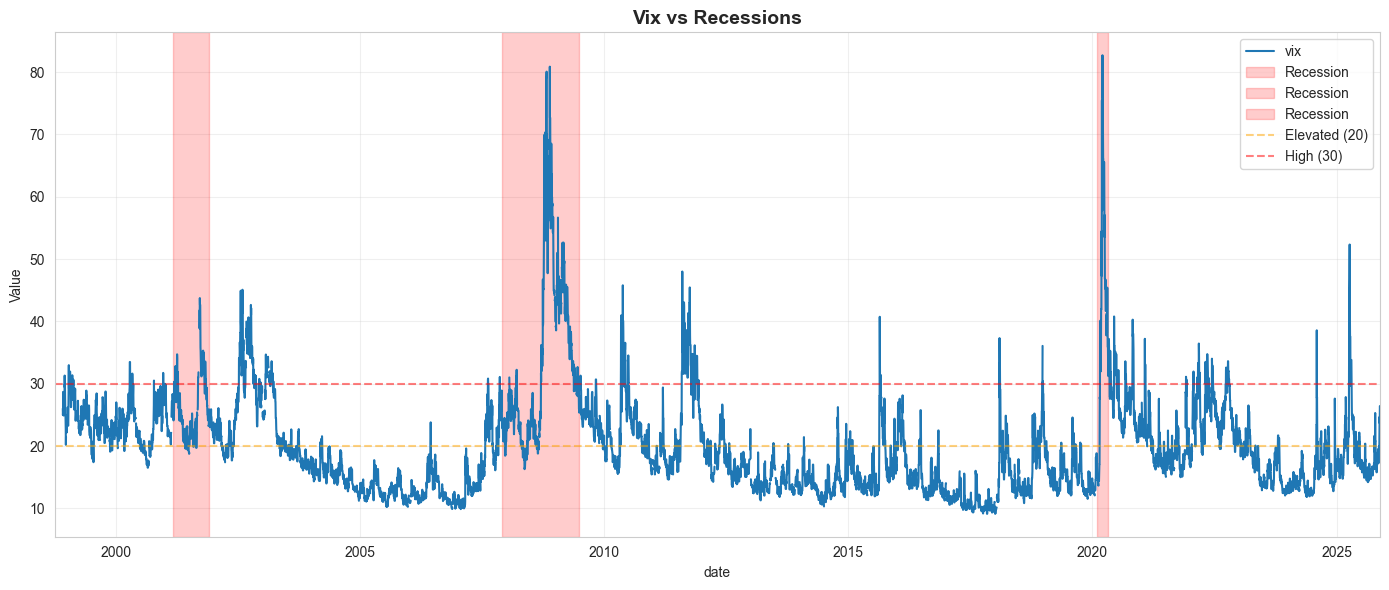


Vix Statistics:
Mean: 19.97
Current: nan
Min: 9.14
Max: 82.69



In [47]:
# Analyze all remaining indicators
remaining_indicators = ['credit_spread', 'gdp', 'consumer_confidence', 'leading_indicators', 
                       'jobless_claims', 'housing_starts', 'retail_sales', 'oil_price', 'vix']

for indicator in remaining_indicators:
    if indicator not in combined_df.columns:
        continue
        
    fig, ax = plt.subplots(figsize=(14, 6))
    
    combined_df[indicator].plot(ax=ax, linewidth=1.5)
    mark_recessions(ax, recession_periods)
    
    # Add special thresholds for specific indicators
    if indicator == 'vix':
        ax.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Elevated (20)')
        ax.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='High (30)')
    elif indicator == 'gdp':
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero Growth')
    elif indicator == 'credit_spread':
        ax.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='Elevated (2.0)')
    
    title = indicator.replace('_', ' ').title()
    ax.set_title(f'{title} vs Recessions', fontsize=14, fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\n{title} Statistics:")
    print(f"Mean: {combined_df[indicator].mean():.2f}")
    print(f"Current: {combined_df[indicator].iloc[-1]:.2f}")
    print(f"Min: {combined_df[indicator].min():.2f}")
    print(f"Max: {combined_df[indicator].max():.2f}")
    print()

## Signal Quality Assessment

Evaluate the predictive power of each indicator.

In [48]:
# Define thresholds for each indicator
thresholds = get_all_indicator_thresholds()

print("Indicator Thresholds:")
for name, threshold in thresholds.items():
    if name in combined_df.columns:
        print(f"  {name}: {threshold}")

Indicator Thresholds:
  yield_curve: {'recession_threshold': -0.5, 'mean': 0.8, 'std': 1.2}
  unemployment: {'recession_threshold': 6.0, 'mean': 5.5, 'std': 1.5}
  gdp: {'recession_threshold': 0.0, 'mean': 2.5, 'std': 2.0}
  consumer_confidence: {'recession_threshold': 70.0, 'mean': 85.0, 'std': 10.0}
  leading_indicators: {'recession_threshold': -1.0, 'mean': 0.0, 'std': 1.5}
  credit_spread: {'recession_threshold': 2.0, 'mean': 1.5, 'std': 0.8, 'description': 'BAA corporate bond spread over 10-year Treasury'}
  housing_starts: {'recession_threshold': 1200, 'mean': 1400, 'std': 300, 'description': 'New privately-owned housing units started (thousands)'}
  retail_sales: {'recession_threshold': 0.0, 'mean': 3.0, 'std': 5.0, 'description': 'Retail sales excluding food services (year-over-year % change)'}
  oil_price: {'recession_threshold': 100.0, 'mean': 65.0, 'std': 25.0, 'description': 'WTI crude oil price ($/barrel)'}
  vix: {'recession_threshold': 25.0, 'mean': 18.0, 'std': 8.0, 'de

In [49]:
# Calculate signal quality metrics
def calculate_signal_metrics(indicator_series, recession_indicator, threshold, invert=False):
    """Calculate true positive rate, false positive rate, etc."""
    # Create signal (1 when threshold crossed)
    if invert:
        signal = (indicator_series < threshold).astype(int)
    else:
        signal = (indicator_series > threshold).astype(int)
    
    # Align with recession indicator
    aligned = pd.DataFrame({
        'signal': signal,
        'recession': recession_indicator
    }).dropna()
    
    # Calculate metrics
    tp = ((aligned['signal'] == 1) & (aligned['recession'] == 1)).sum()
    fp = ((aligned['signal'] == 1) & (aligned['recession'] == 0)).sum()
    tn = ((aligned['signal'] == 0) & (aligned['recession'] == 0)).sum()
    fn = ((aligned['signal'] == 0) & (aligned['recession'] == 1)).sum()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # True positive rate (sensitivity)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False positive rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    
    return {
        'tpr': tpr,
        'fpr': fpr,
        'precision': precision,
        'accuracy': accuracy,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }

print("✓ Signal quality function defined")

✓ Signal quality function defined


In [50]:
# Analyze key indicators
signal_quality = {}

if 'yield_curve' in combined_df.columns:
    signal_quality['yield_curve'] = calculate_signal_metrics(
        combined_df['yield_curve'], 
        recession_indicator, 
        threshold=0, 
        invert=True  # Inversion (negative) signals recession
    )

if 'unemployment' in combined_df.columns:
    # Use 3-month change as signal
    unemployment_change = combined_df['unemployment'].diff(periods=90)
    signal_quality['unemployment_change'] = calculate_signal_metrics(
        unemployment_change,
        recession_indicator,
        threshold=0.5,  # Rising unemployment
        invert=False
    )

if 'credit_spread' in combined_df.columns:
    signal_quality['credit_spread'] = calculate_signal_metrics(
        combined_df['credit_spread'],
        recession_indicator,
        threshold=2.0,  # Widening spread
        invert=False
    )

# Display results
print("\nSignal Quality Metrics:\n")
for indicator, metrics in signal_quality.items():
    print(f"{indicator}:")
    print(f"  True Positive Rate (Sensitivity): {metrics['tpr']*100:.1f}%")
    print(f"  False Positive Rate: {metrics['fpr']*100:.1f}%")
    print(f"  Precision: {metrics['precision']*100:.1f}%")
    print(f"  Accuracy: {metrics['accuracy']*100:.1f}%")
    print()


Signal Quality Metrics:

yield_curve:
  True Positive Rate (Sensitivity): 0.0%
  False Positive Rate: 15.8%
  Precision: 0.0%
  Accuracy: 76.2%

unemployment_change:
  True Positive Rate (Sensitivity): 50.6%
  False Positive Rate: 1.0%
  Precision: 84.3%
  Accuracy: 94.4%

credit_spread:
  True Positive Rate (Sensitivity): 96.0%
  False Positive Rate: 64.5%
  Precision: 13.5%
  Accuracy: 41.3%



## Summary and Conclusions

Key findings from indicator analysis.

In [51]:
print("Key Findings:")
print("\n1. Yield Curve:")
print("   - Inversions typically precede recessions by 6-18 months")
print("   - Strong leading indicator with high sensitivity")
print("\n2. Unemployment Rate:")
print("   - Rate of change more predictive than absolute level")
print("   - Tends to lag recession onset but confirms downturn")
print("\n3. Credit Spread:")
print("   - Widening spreads indicate increased risk perception")
print("   - Can spike sharply before and during recessions")
print("\n4. Other Indicators:")
print("   - GDP: Negative growth confirms recession")
print("   - Consumer Confidence: Drops before recessions")
print("   - VIX: Spikes during market stress")
print("   - Housing Starts: Leading indicator of economic activity")
print("\n5. Optimal Thresholds:")
print("   - Yield curve: < 0 (inversion)")
print("   - Unemployment change: > 0.5% over 3 months")
print("   - Credit spread: > 2.0%")

Key Findings:

1. Yield Curve:
   - Inversions typically precede recessions by 6-18 months
   - Strong leading indicator with high sensitivity

2. Unemployment Rate:
   - Rate of change more predictive than absolute level
   - Tends to lag recession onset but confirms downturn

3. Credit Spread:
   - Widening spreads indicate increased risk perception
   - Can spike sharply before and during recessions

4. Other Indicators:
   - GDP: Negative growth confirms recession
   - Consumer Confidence: Drops before recessions
   - VIX: Spikes during market stress
   - Housing Starts: Leading indicator of economic activity

5. Optimal Thresholds:
   - Yield curve: < 0 (inversion)
   - Unemployment change: > 0.5% over 3 months
   - Credit spread: > 2.0%
